## Clone the Repository

In [4]:
# Clone the project from GitHub
!git clone https://github.com/HamzaGbada/medical-ai-test.git
%cd medical-ai-test

Cloning into 'medical-ai-test'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (237/237), done.
remote: Compressing objects: 100% (143/143), done.
remote: Total 237 (delta 84), reused 237 (delta 84), pack-reused 0 (from 0)
Receiving objects: 100% (237/237), 3.19 MiB | 44.15 MiB/s, done.
Resolving deltas: 100% (84/84), done.
/content/medical-ai-test


## Install dependencies

In [1]:
!pip install -q \
    torch torchvision \
    medmnist>=2.2.0 \
    numpy pandas matplotlib seaborn \
    scikit-learn tqdm pyyaml \
    Pillow

In [2]:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")


PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


# Explore the Dataset (PneumoniaMNIST)

Train samples : 4708
Val samples   : 524
Test samples  : 624
Classes       : Normal (0), Pneumonia (1)


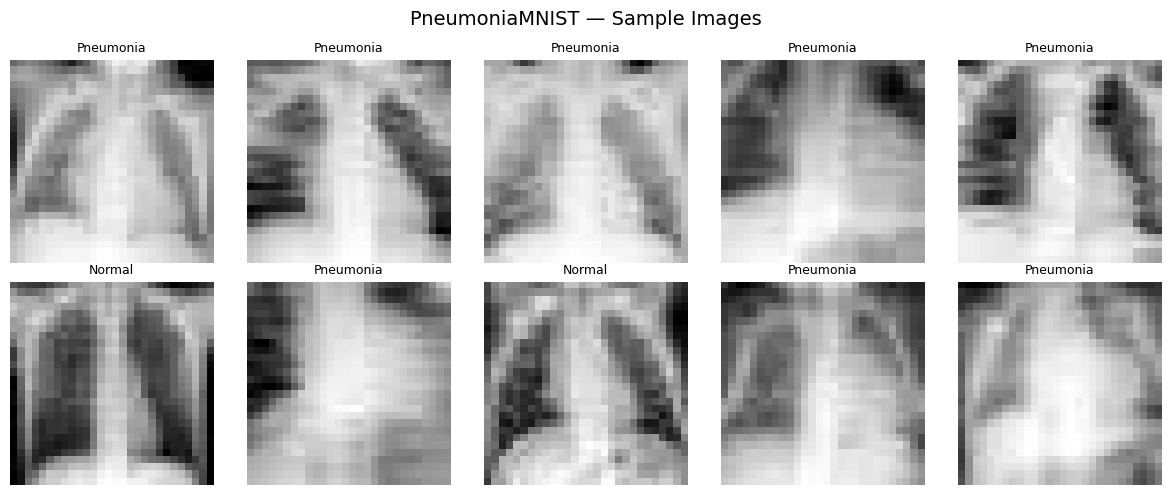

In [5]:
import medmnist
from medmnist import PneumoniaMNIST
import matplotlib.pyplot as plt
import numpy as np

# Auto-download the dataset
train_data = PneumoniaMNIST(split="train", download=True, size=28)
val_data   = PneumoniaMNIST(split="val",   download=True, size=28)
test_data  = PneumoniaMNIST(split="test",  download=True, size=28)

print(f"Train samples : {len(train_data)}")
print(f"Val samples   : {len(val_data)}")
print(f"Test samples  : {len(test_data)}")
print(f"Classes       : Normal (0), Pneumonia (1)")

# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("PneumoniaMNIST — Sample Images", fontsize=14)
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(np.array(img).squeeze(), cmap="gray")
    ax.set_title(f"{'Pneumonia' if label[0]==1 else 'Normal'}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("reports/sample_images.png", dpi=120)
plt.show()

## Train a Single Model (Quick Test)

### ResNet18 Pretrained (recommended for quick start)


In [6]:
!python -m task1_classification.train \
    --model resnet \
    --pretrained true \
    --epochs 15 \
    --seed 42

2026-02-22 14:33:33 [INFO] __main__: Random seed set to 42
2026-02-22 14:33:33 [INFO] __main__: Using GPU: Tesla T4
2026-02-22 14:33:33 [INFO] __main__: ============================================================
2026-02-22 14:33:33 [INFO] __main__: Starting experiment: resnet_pretrained
2026-02-22 14:33:33 [INFO] __main__: ============================================================
100% 4.17M/4.17M [00:01<00:00, 2.69MB/s]
2026-02-22 14:33:36 [INFO] data.dataset: Loaded PneumoniaMNIST train split: 4708 samples, 1 classes (binary-class)
2026-02-22 14:33:36 [INFO] data.dataset: Loaded PneumoniaMNIST val split: 524 samples, 1 classes (binary-class)
2026-02-22 14:33:36 [INFO] data.dataset: Loaded PneumoniaMNIST test split: 624 samples, 1 classes (binary-class)
2026-02-22 14:33:36 [INFO] data.dataloaders: Class distribution (train): {'Normal': 1214, 'Pneumonia': 3494}
2026-02-22 14:33:36 [INFO] data.dataloaders: Class distribution (val): {'Normal': 135, 'Pneumonia': 389}
2026-02-22 14:33:

## Train All 6 Architectures (Full Experiment)


In [9]:
!python -m task1_classification.experiment_runner


2026-02-22 14:59:58 [INFO] __main__: ======================================================================
2026-02-22 14:59:58 [INFO] __main__: EXPERIMENT 1/6: unet_scratch
2026-02-22 14:59:58 [INFO] __main__: ======================================================================
2026-02-22 14:59:58 [INFO] task1_classification.train: Random seed set to 42
2026-02-22 14:59:58 [INFO] task1_classification.train: Using GPU: Tesla T4
2026-02-22 14:59:58 [INFO] task1_classification.train: ============================================================
2026-02-22 14:59:58 [INFO] task1_classification.train: Starting experiment: unet_scratch
2026-02-22 14:59:58 [INFO] task1_classification.train: ============================================================
2026-02-22 14:59:58 [INFO] data.dataset: Loaded PneumoniaMNIST train split: 4708 samples, 1 classes (binary-class)
2026-02-22 14:59:58 [INFO] data.dataset: Loaded PneumoniaMNIST val split: 524 samples, 1 classes (binary-class)
2026-02-22 14:59:5

## Evaluate a Trained Model


In [10]:
!python -m task1_classification.evaluate \
    --model resnet \
    --pretrained true

2026-02-22 15:11:04 [INFO] __main__: Evaluating: resnet_pretrained
2026-02-22 15:11:04 [INFO] models.resnet_classifier: ResNetClassifier initialized (pretrained=True, in_channels=1)
2026-02-22 15:11:04 [INFO] models.utils: Created model 'resnet' (pretrained=True): 11,170,753 trainable parameters
2026-02-22 15:11:05 [INFO] __main__: Loaded checkpoint: ./checkpoints/resnet_pretrained_best.pth
2026-02-22 15:11:05 [INFO] data.dataset: Loaded PneumoniaMNIST train split: 4708 samples, 1 classes (binary-class)
2026-02-22 15:11:05 [INFO] data.dataset: Loaded PneumoniaMNIST val split: 524 samples, 1 classes (binary-class)
2026-02-22 15:11:05 [INFO] data.dataset: Loaded PneumoniaMNIST test split: 624 samples, 1 classes (binary-class)
2026-02-22 15:11:05 [INFO] data.dataloaders: Class distribution (train): {'Normal': 1214, 'Pneumonia': 3494}
2026-02-22 15:11:05 [INFO] data.dataloaders: Class distribution (val): {'Normal': 135, 'Pneumonia': 389}
2026-02-22 15:11:05 [INFO] data.dataloaders: Class d

## Visualize Results

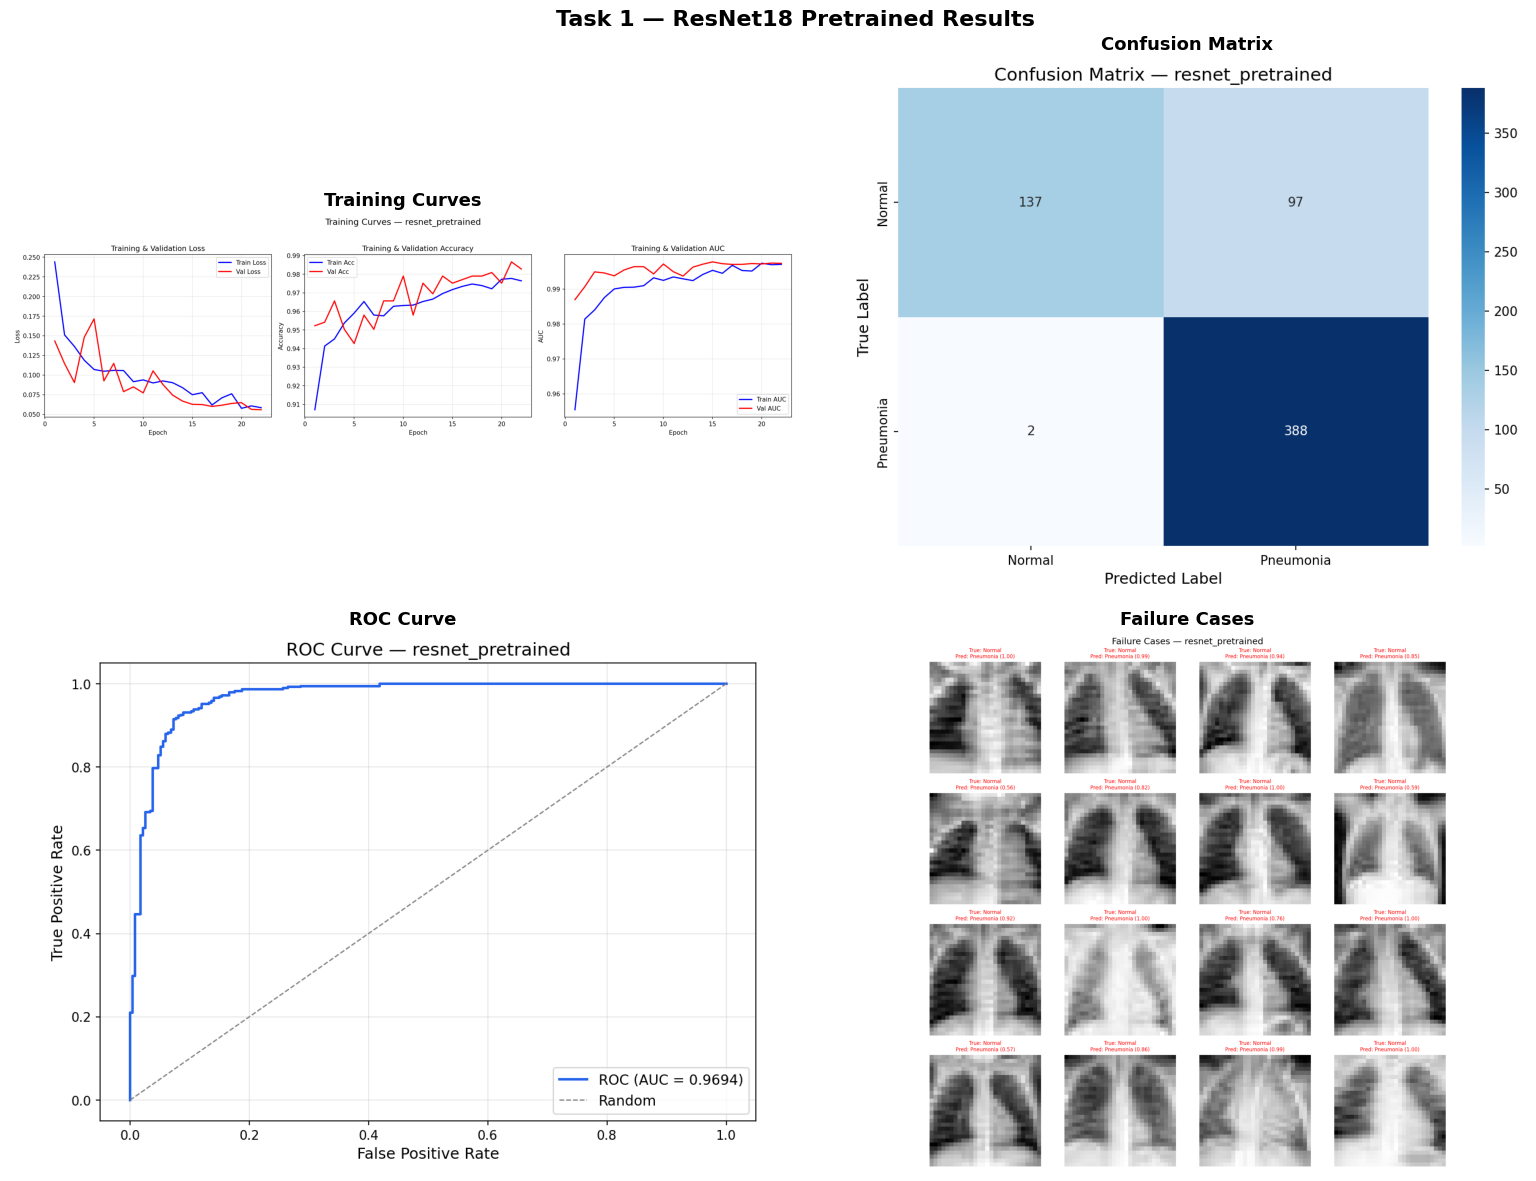

In [11]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

reports_dir = "reports"
plots = {
    "Training Curves"  : "resnet_pretrained_training_curves.png",
    "Confusion Matrix" : "resnet_pretrained_confusion_matrix.png",
    "ROC Curve"        : "resnet_pretrained_roc_curve.png",
    "Failure Cases"    : "resnet_pretrained_failure_cases.png",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (title, fname) in zip(axes.flat, plots.items()):
    fpath = os.path.join(reports_dir, fname)
    if os.path.exists(fpath):
        img = mpimg.imread(fpath)
        ax.imshow(img)
        ax.set_title(title, fontsize=13, fontweight="bold")
    else:
        ax.text(0.5, 0.5, f"File not found:\n{fname}", ha="center", va="center", color="red")
    ax.axis("off")
plt.suptitle("Task 1 — ResNet18 Pretrained Results", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/task1_overview.png", dpi=120)
plt.show()

## Compare All 6 Models

FULL 6-MODEL COMPARISON
       Model    Variant              Experiment  Parameters  Training Time (s)  Epochs Trained  Best Val AUC  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
        unet    Scratch            unet_scratch     7849025              99.92              24        0.9974         0.8622          0.8193       1.0000   0.9007        0.9769
        unet Pretrained         unet_pretrained    11859777              79.97              18        0.9970         0.8942          0.8568       0.9974   0.9218        0.9649
      resnet    Scratch          resnet_scratch    11170753              71.50              17        0.9967         0.8846          0.8581       0.9769   0.9137        0.9604
      resnet Pretrained       resnet_pretrained    11170753              92.44              22        0.9978         0.8413          0.8000       0.9949   0.8869        0.9694
efficientnet    Scratch    efficientnet_scratch     4008253             131.67              24  

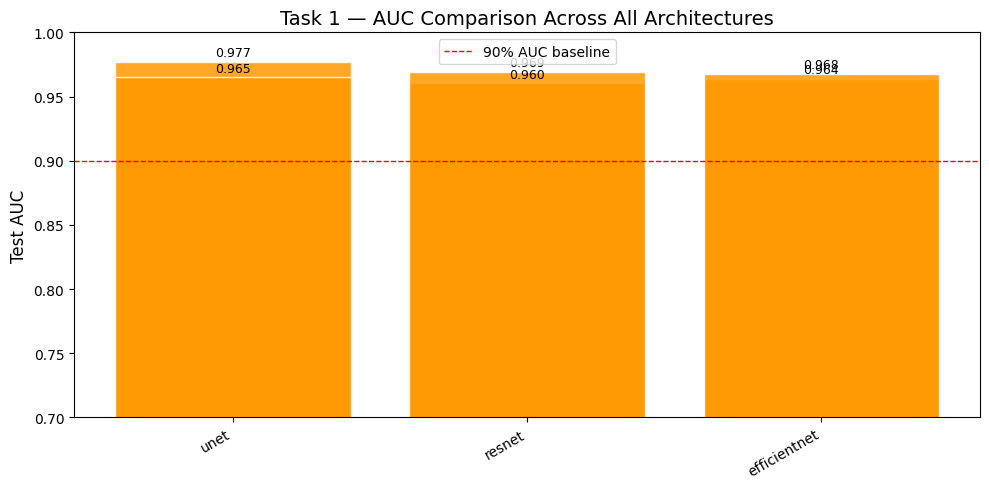

In [16]:
import pandas as pd

csv_path = "reports/experiment_comparison.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("=" * 70)
    print("FULL 6-MODEL COMPARISON")
    print("=" * 70)
    print(df.to_string(index=False))

    # Plot AUC comparison
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#2196F3" if "pretrained" in str(r).lower() else "#FF9800" for r in df["Model"]]
    bars = ax.bar(df["Model"], df["Test ROC-AUC"], color=colors, alpha=0.85, edgecolor="white")
    ax.set_ylim(0.7, 1.0)
    ax.set_ylabel("Test AUC", fontsize=12)
    ax.set_title("Task 1 — AUC Comparison Across All Architectures", fontsize=14)
    ax.axhline(0.90, color="red", linestyle="--", linewidth=1, label="90% AUC baseline")
    ax.legend()
    for bar, val in zip(bars, df["Test ROC-AUC"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("reports/task1_auc_comparison.png", dpi=120)
    plt.show()
else:
    print("⚠️  Run Cell 5 (experiment_runner) first to generate all results.")


## Print Metrics Summary

In [17]:
import json, glob

print("=" * 60)
print("TASK 1 — TEST METRICS SUMMARY")
print("=" * 60)

result_files = sorted(glob.glob("results/*_test_metrics.json"))
if result_files:
    rows = []
    for fpath in result_files:
        with open(fpath) as f:
            m = json.load(f)
        name = os.path.basename(fpath).replace("_test_metrics.json", "")
        rows.append({
            "Model"     : name,
            "Accuracy"  : f"{m.get('accuracy', 0):.4f}",
            "AUC"       : f"{m.get('auc', 0):.4f}",
            "F1"        : f"{m.get('f1', 0):.4f}",
            "Precision" : f"{m.get('precision', 0):.4f}",
            "Recall"    : f"{m.get('recall', 0):.4f}",
        })
    df_metrics = pd.DataFrame(rows)
    print(df_metrics.to_string(index=False))
else:
    print("No result files found yet. Run training and evaluation first.")

TASK 1 — TEST METRICS SUMMARY
                  Model Accuracy    AUC     F1 Precision Recall
efficientnet_pretrained   0.8942 0.0000 0.9218    0.8568 0.9974
   efficientnet_scratch   0.8782 0.0000 0.9097    0.8473 0.9821
      resnet_pretrained   0.8413 0.0000 0.8869    0.8000 0.9949
         resnet_scratch   0.8846 0.0000 0.9137    0.8581 0.9769
        unet_pretrained   0.8942 0.0000 0.9218    0.8568 0.9974
           unet_scratch   0.8622 0.0000 0.9007    0.8193 1.0000
